Breast Cancer Dataset (Binary Classification)
Built into sklearn
Real medical dataset
Predict: Malignant (0) or Benign (1)

Loading and exploring data

In [43]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# method 1 to load data
cancer= load_breast_cancer()
df=pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
# print(df.head())

# method 2 to load data
# cancer = load_breast_cancer()
# X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
# y = pd.Series(cancer.target)

print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['target'].value_counts()}")



Dataset shape: (569, 31)
Target distribution:
target
1    357
0    212
Name: count, dtype: int64


Data visualization
1.Class distribution

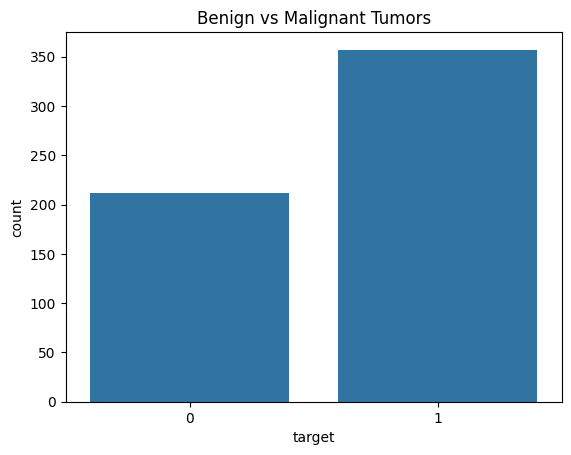

In [42]:
sns.countplot(x='target', data=df)
plt.title('Benign vs Malignant Tumors')
plt.show()

2. Feature Distribution

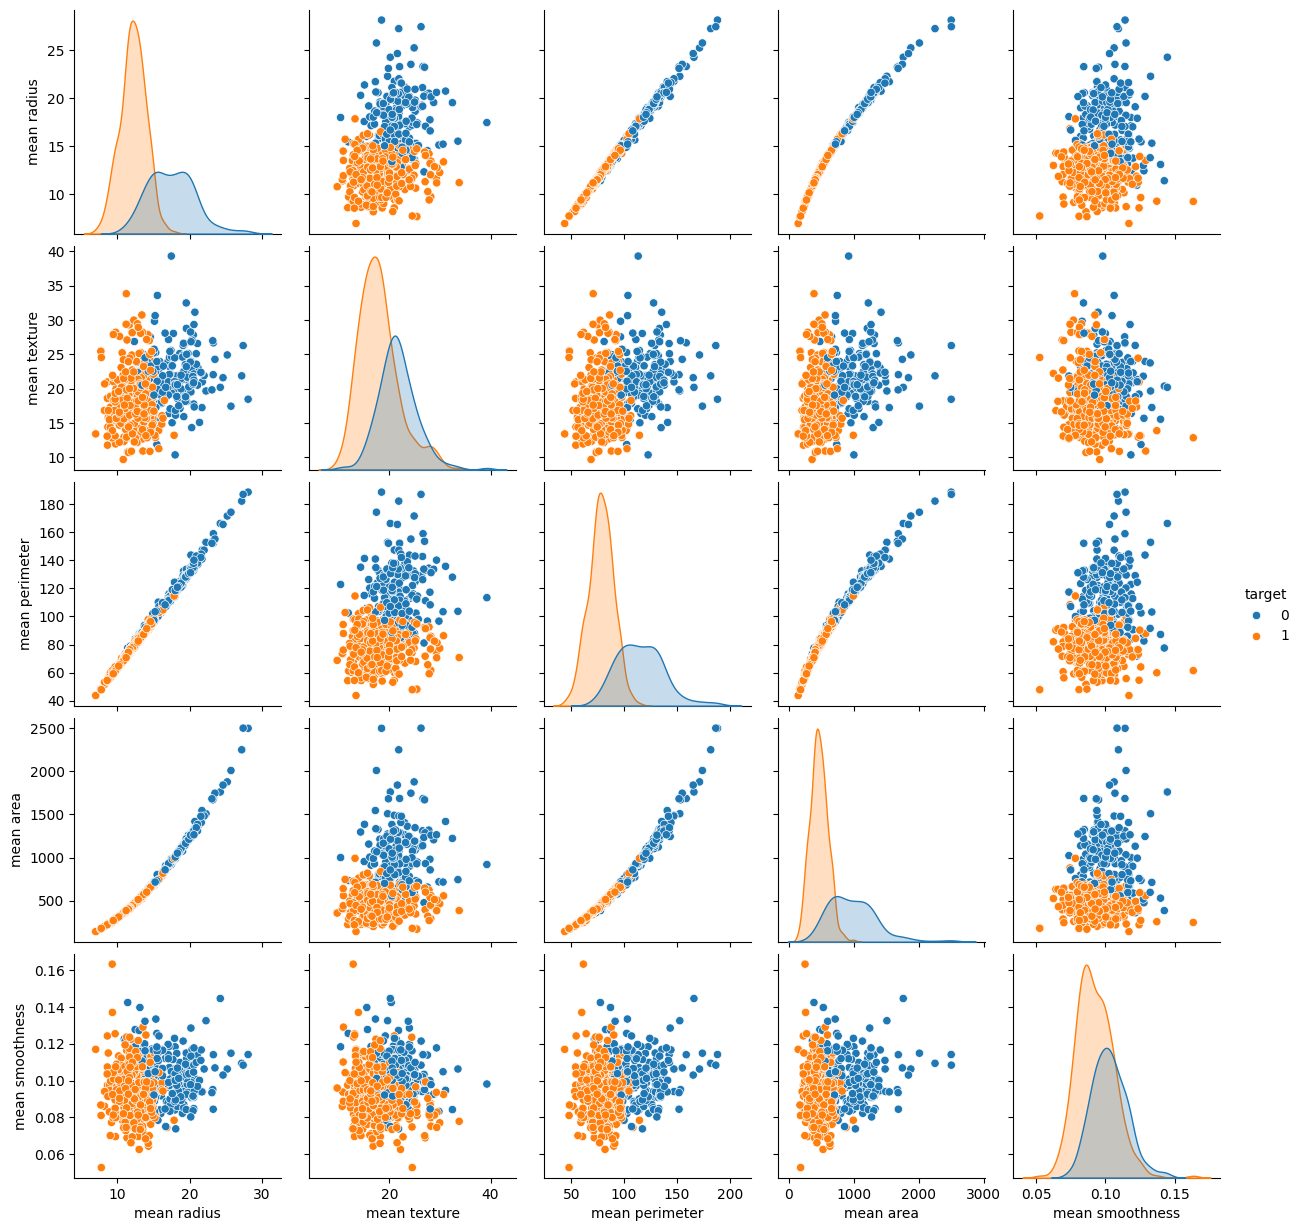

In [44]:
# Select first 5 features
features = df.columns[:5]
sns.pairplot(df, hue='target', vars=features)
plt.show()   

3. Correlation heatmap

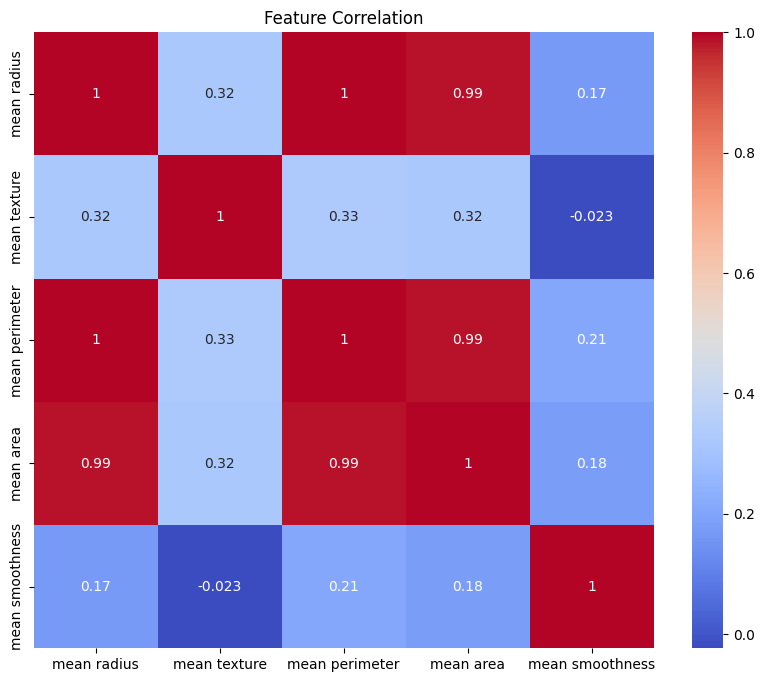

In [45]:
# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()   

Splitting data

In [32]:

x_train, x_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=42)


In [33]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [34]:
from sklearn.linear_model import LogisticRegression
model= LogisticRegression(random_state=42)
model.fit(x_train_scaled, y_train)

LogisticRegression(random_state=42)

In [39]:
y_pred=model.predict(x_test)
# Get prediction probabilities
y_pred_proba = model.predict_proba(x_test)

In [37]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(x_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))   

Accuracy: 0.974
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



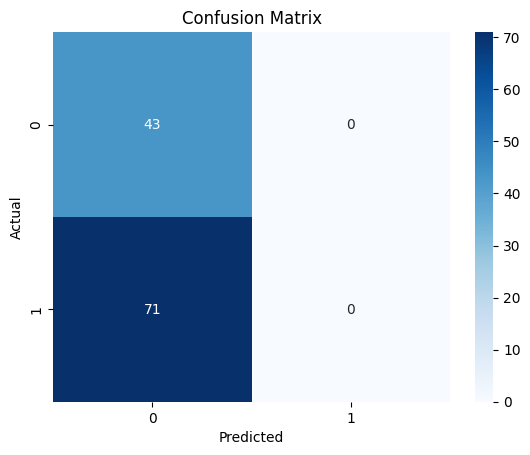

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()